# Vanility — Synthetic Dataset Generation & Grading Model (REVISED)

Notebook ini adalah revisi dari `vanility_ml_model.ipynb` sebelumnya, dengan threshold yang
disesuaikan berdasarkan riset ulang terhadap literatur curing vanili dan SNI 01-0010-2002.

## Ringkasan revisi vs versi sebelumnya

| Aspek | Versi lama | Versi revisi | Alasan |
|---|---|---|---|
| Harvest window ideal | 210-270 hari | **240-270 hari** | Sumber curing tradisional konsisten menyebut window ideal 8-9 bulan (240-270 hari), bukan 7-9 bulan |
| Sun drying ideal | 5-14 hari (>25 hari = risiko tinggi) | **15-35 hari ideal, <10 hari = under-dried, >45 hari = over-dried** | Data grading menunjukkan durasi drying yang LEBIH PANJANG berkorelasi dengan grade lebih tinggi (Grade A ~35 hari vs Grade D 2-8 hari) — arah lama justru terbalik |
| Conditioning ideal | ≥60 hari | **≥45 hari** (dipertahankan mendekati 60) | Riset menemukan 1,5 bulan (~45 hari) dengan kemasan HDPE + suhu 35°C sudah menghasilkan kualitas sesuai SNI dengan kadar vanilin tinggi — lebih cepat dari asumsi tradisional 90-120 hari |
| Kadar vanilin (referensi teks) | disebut minimum 1,00% | **perlu verifikasi lanjut** — ditemukan angka 2,983% untuk Mutu I A di beberapa sumber sekunder; rekomendasi cek dokumen SNI asli sebelum dikutip ke juri |

**Catatan penting:** dataset ini tetap 100% sintetis (rule-distillation), bukan data lapangan
riil. Confidence score dari `predict_proba()` mencerminkan konsistensi internal model
terhadap pola sintetis, bukan validasi terhadap hasil uji lab vanilin sungguhan. Frame ini
sebagai *"estimasi awal berbasis praktik terbaik/SNI,"* bukan pengganti uji lab, saat presentasi.


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import random

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


## 2. Generate Raw Synthetic Features

Sampling fitur mentah secara random dalam rentang realistis (bukan grid rapi), termasuk beberapa kombinasi kasus khusus (mis. `curing_method` yang tidak sesuai durasi idealnya).

In [2]:
N_ROWS = 700

def generate_raw_dataset(n=N_ROWS):
    rows = []
    for _ in range(n):
        days_since_pollination = np.random.randint(60, 331)
        curing_method = random.choice(["tradisional", "terkontrol"])

        # Sengaja masukkan beberapa kasus mismatch (curing_method vs durasi)
        # supaya model belajar pola general, bukan cuma menghafal kombinasi "rapi"
        sweating_duration_days = np.random.randint(0, 21)
        sun_drying_duration_days = np.random.randint(0, 51)   # diperluas sampai 50 hari
                                                                 # supaya cakup kasus over-dried
        conditioning_duration_days = np.random.randint(0, 121)
        quantity_kg_wet = round(np.random.uniform(2, 50), 1)

        rows.append({
            "days_since_pollination": days_since_pollination,
            "curing_method": curing_method,
            "sweating_duration_days": sweating_duration_days,
            "sun_drying_duration_days": sun_drying_duration_days,
            "conditioning_duration_days": conditioning_duration_days,
            "quantity_kg_wet": quantity_kg_wet,
        })
    return pd.DataFrame(rows)

raw_df = generate_raw_dataset()
raw_df.head()


,days_since_pollination,curing_method,sweating_duration_days,sun_drying_duration_days,conditioning_duration_days,quantity_kg_wet
0,162,tradisional,19,28,14,37.1
1,248,tradisional,20,38,82,6.8
2,147,terkontrol,20,35,103,36.0
3,209,tradisional,20,1,87,42.0
4,251,tradisional,20,32,75,31.4


## 3. Rule-Based Label Generator (REVISED)

Logic di bawah ini menjadi *ground truth generator* untuk melabeli dataset sintetis.
Referensi: SNI 01-0010-2002, riset conditioning terkontrol (Jurnal Teknik Pertanian
Lampung), dan literatur curing tradisional (Bourbon method).

### Step 1 — Harvest timing
Window ideal direvisi ke **240-270 hari (8-9 bulan)**, sesuai referensi curing
tradisional yang konsisten menyebut panen ideal 8 sampai 9 bulan setelah penyerbukan.

In [3]:
def score_harvest(days_since_pollination):
    """Step 1: cek waktu panen (REVISED: window ideal 240-270 hari)."""
    if days_since_pollination < 210:
        return "terlalu_dini", 0
    elif days_since_pollination < 240:
        return "mendekati_matang", 1
    elif 240 <= days_since_pollination <= 270:
        return "matang_ideal", 2
    else:
        return "lewat_matang", 1


### Step 2 — Curing stages (REVISED)

- **Sweating**: dipertahankan (10-15 hari tradisional / 4-8 hari terkontrol), konsisten dengan
  beberapa sumber curing tradisional dan metode termodifikasi.
- **Sun drying**: **direvisi total**. Data menunjukkan Grade A membutuhkan durasi drying
  lebih panjang (~35 hari) dibanding grade rendah (2-10 hari) — arah sebaliknya dari asumsi versi lama.
  Drying terlalu singkat (<10 hari) = under-dried / pengembangan vanilin belum sempurna.
  Drying terlalu lama (>45 hari) = risiko over-dried, vanillin rusak, tekstur getas.
- **Conditioning**: threshold skor maksimal diturunkan ke **≥45 hari**, mengikuti riset yang
  menemukan hasil sesuai SNI dengan conditioning 1,5 bulan pada kemasan dan suhu terkontrol.

In [4]:
def score_curing(curing_method, sweating_duration_days, sun_drying_duration_days, conditioning_duration_days):
    """Step 2: cek kelengkapan dan durasi tiap tahap curing (REVISED)."""

    # --- Sweating (tidak berubah dari versi sebelumnya) ---
    if sweating_duration_days == 0:
        sweating_score = 0
    elif curing_method == "terkontrol" and 4 <= sweating_duration_days <= 8:
        sweating_score = 2
    elif curing_method == "tradisional" and 10 <= sweating_duration_days <= 15:
        sweating_score = 2
    elif sweating_duration_days > 0:
        sweating_score = 1
    else:
        sweating_score = 0

    # --- Sun drying (REVISED: durasi lebih panjang = lebih baik, sampai batas over-dry) ---
    if sun_drying_duration_days < 10:
        # terlalu cepat: under-dried, pengembangan vanilin belum optimal
        drying_score = 0
    elif sun_drying_duration_days < 15:
        drying_score = 1
    elif 15 <= sun_drying_duration_days <= 35:
        # rentang ideal, mencakup durasi khas Grade A (~35 hari)
        drying_score = 2
    elif 35 < sun_drying_duration_days <= 45:
        # diperpanjang, hasil masih dapat diterima tapi diminishing returns
        drying_score = 1
    else:
        # >45 hari: risiko over-dried, vanillin rusak, tekstur getas
        drying_score = 0

    # --- Conditioning (REVISED: threshold turun ke 45 hari) ---
    if conditioning_duration_days >= 45:
        conditioning_score = 2
    elif conditioning_duration_days >= 20:
        conditioning_score = 1
    else:
        conditioning_score = 0

    return sweating_score, drying_score, conditioning_score


### Step 3 — Kombinasikan skor menjadi grade akhir (tidak berubah dari versi sebelumnya)

In [5]:
def combine_grade(harvest_score, sweating_score, drying_score, conditioning_score):
    """Step 3: kombinasikan skor menjadi grade akhir."""
    total_score = harvest_score + sweating_score + drying_score + conditioning_score

    if total_score >= 6:
        predicted_grade = "A"
        confidence_score = 0.85 + (total_score - 6) * 0.05
    elif total_score >= 3:
        predicted_grade = "B"
        confidence_score = 0.60 + (total_score - 3) * 0.05
    else:
        predicted_grade = "Rendah"
        confidence_score = 0.50 + total_score * 0.03

    # Kasus khusus: panen terlalu dini langsung cap grade maksimum di "Rendah"
    if harvest_score == 0:
        predicted_grade = "Rendah"
        confidence_score = min(confidence_score, 0.55)

    return total_score, predicted_grade, round(confidence_score, 4)


### Step 4 — Generate rekomendasi teks (disesuaikan dengan threshold baru)

In [6]:
def generate_recommendations(harvest_score, sweating_score, drying_score, conditioning_score):
    """Step 4: generate rekomendasi teks berdasarkan skor terendah (REVISED text)."""
    recommendations = []
    if harvest_score < 2:
        recommendations.append(
            "Tunggu hingga usia polong mencapai 8-9 bulan sejak penyerbukan untuk kadar vanilin optimal."
        )
    if sweating_score < 2:
        recommendations.append(
            "Lakukan sweating minimal 10-15 hari (tradisional) atau 4-8 hari jika menggunakan pengering terkontrol."
        )
    if drying_score < 2:
        recommendations.append(
            "Jaga durasi penjemuran di kisaran 15-35 hari — terlalu singkat (<10 hari) membuat kadar vanilin belum optimal, "
            "terlalu lama (>45 hari) berisiko over-dried dan merusak vanilin."
        )
    if conditioning_score < 2:
        recommendations.append(
            "Simpan hasil curing dalam kotak/kemasan tertutup minimal 45 hari pada suhu terkontrol untuk pematangan aroma optimal."
        )
    return recommendations


## 4. Terapkan Label Generator ke Raw Dataset

In [7]:
def label_row(row):
    harvest_status, harvest_score = score_harvest(row["days_since_pollination"])
    sweating_score, drying_score, conditioning_score = score_curing(
        row["curing_method"],
        row["sweating_duration_days"],
        row["sun_drying_duration_days"],
        row["conditioning_duration_days"],
    )
    total_score, predicted_grade, confidence_score = combine_grade(
        harvest_score, sweating_score, drying_score, conditioning_score
    )
    recommendations = generate_recommendations(
        harvest_score, sweating_score, drying_score, conditioning_score
    )
    return pd.Series({
        "harvest_status": harvest_status,
        "harvest_score": harvest_score,
        "sweating_score": sweating_score,
        "drying_score": drying_score,
        "conditioning_score": conditioning_score,
        "total_score": total_score,
        "predicted_grade": predicted_grade,
        "confidence_score": confidence_score,
        "recommendations": recommendations,
    })

labels_df = raw_df.apply(label_row, axis=1)
dataset_df = pd.concat([raw_df, labels_df], axis=1)
dataset_df["predicted_grade"].value_counts()


predicted_grade
Rendah    415
B         171
A         114
Name: count, dtype: int64

## 5. Feature Engineering + Label Noise

In [8]:
# Feature engineering
dataset_df["total_curing_duration_days"] = (
    dataset_df["sweating_duration_days"]
    + dataset_df["sun_drying_duration_days"]
    + dataset_df["conditioning_duration_days"]
)
dataset_df["harvest_deviation_days"] = (dataset_df["days_since_pollination"] - 240).abs()

# Label noise: flip grade secara random pada ~4% baris,
# supaya model belajar pola general, bukan menghafal threshold persis
NOISE_FRACTION = 0.04
grades = ["A", "B", "Rendah"]
noise_idx = dataset_df.sample(frac=NOISE_FRACTION, random_state=RANDOM_SEED).index
for idx in noise_idx:
    current = dataset_df.loc[idx, "predicted_grade"]
    choices = [g for g in grades if g != current]
    dataset_df.loc[idx, "predicted_grade"] = random.choice(choices)

print(f"Jumlah baris di-noise: {len(noise_idx)} dari {len(dataset_df)} ({NOISE_FRACTION*100:.0f}%)")
dataset_df["predicted_grade"].value_counts()


Jumlah baris di-noise: 28 dari 700 (4%)


predicted_grade
Rendah    398
B         181
A         121
Name: count, dtype: int64

## 6. Simpan Dataset Sintetis

In [9]:
import os
os.makedirs("data", exist_ok=True)
dataset_df.to_csv("data/synthetic_vanilla_dataset.csv", index=False)
print("Tersimpan di data/synthetic_vanilla_dataset.csv")
dataset_df.head()


Tersimpan di data/synthetic_vanilla_dataset.csv


,days_since_pollination,curing_method,sweating_duration_days,sun_drying_duration_days,conditioning_duration_days,quantity_kg_wet,harvest_status,harvest_score,sweating_score,drying_score,conditioning_score,total_score,predicted_grade,confidence_score,recommendations,total_curing_duration_days,harvest_deviation_days
0,162,tradisional,19,28,14,37.1,terlalu_dini,0,1,2,0,3,Rendah,0.55,[Tunggu hingga usia polong mencapai 8-9 bulan ...,61,78
1,248,tradisional,20,38,82,6.8,matang_ideal,2,1,1,2,6,A,0.85,[Lakukan sweating minimal 10-15 hari (tradisio...,140,8
2,147,terkontrol,20,35,103,36.0,terlalu_dini,0,1,2,2,5,Rendah,0.55,[Tunggu hingga usia polong mencapai 8-9 bulan ...,158,93
3,209,tradisional,20,1,87,42.0,terlalu_dini,0,1,0,2,3,Rendah,0.55,[Tunggu hingga usia polong mencapai 8-9 bulan ...,108,31
4,251,tradisional,20,32,75,31.4,matang_ideal,2,1,2,2,7,A,0.90,[Lakukan sweating minimal 10-15 hari (tradisio...,127,11


## 6b. Exploratory Data Analysis (EDA)

Sebelum training, cek dulu bentuk dataset sintetis: distribusi grade, sebaran fitur numerik
per grade, dan korelasi antar fitur. Ini penting buat mastiin dataset ga bias/timpang secara
ga sengaja, dan buat validasi kalau arah hubungan fitur-ke-grade sesuai revisi logic yang
udah dibahas (misal: durasi sun drying yang lebih panjang harusnya asosiasi ke grade lebih tinggi).

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


### Distribusi umum dataset

In [11]:
print("Jumlah baris:", len(dataset_df))
print()
print("Distribusi predicted_grade:")
print(dataset_df["predicted_grade"].value_counts())
print()
print("Distribusi curing_method:")
print(dataset_df["curing_method"].value_counts())
print()
dataset_df[[
    "days_since_pollination", "sweating_duration_days", "sun_drying_duration_days",
    "conditioning_duration_days", "total_curing_duration_days", "harvest_deviation_days"
]].describe()


Jumlah baris: 700

Distribusi predicted_grade:
predicted_grade
Rendah    398
B         181
A         121
Name: count, dtype: int64

Distribusi curing_method:
curing_method
tradisional    356
terkontrol     344
Name: count, dtype: int64



,days_since_pollination,sweating_duration_days,sun_drying_duration_days,conditioning_duration_days,total_curing_duration_days,harvest_deviation_days
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,189.817143,9.965714,25.297143,57.941429,93.204286,76.908571
std,77.869196,6.050240,14.556200,35.045660,37.533805,51.595962
min,60.000000,0.000000,0.000000,0.000000,6.000000,0.000000
25%,124.000000,5.000000,13.000000,28.000000,63.000000,34.000000
50%,189.000000,10.000000,25.000000,55.500000,90.000000,69.000000
75%,254.000000,15.000000,37.000000,89.000000,122.250000,116.000000
max,330.000000,20.000000,50.000000,120.000000,183.000000,180.000000


### Distribusi grade (count plot)

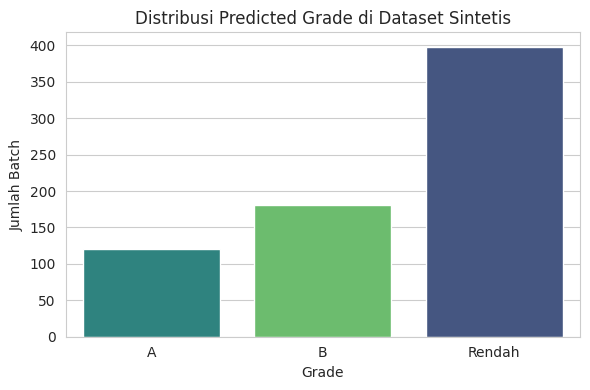

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ["A", "B", "Rendah"]
sns.countplot(data=dataset_df, x="predicted_grade", hue="predicted_grade", order=order, ax=ax, palette="viridis", legend=False)
ax.set_title("Distribusi Predicted Grade di Dataset Sintetis")
ax.set_xlabel("Grade")
ax.set_ylabel("Jumlah Batch")
plt.tight_layout()
plt.show()


### Sebaran fitur numerik per grade (boxplot)

Ini yang paling penting buat validasi arah logic: kalau revisi `drying_score` udah benar,
`sun_drying_duration_days` untuk Grade A seharusnya cenderung lebih tinggi (bukan lebih rendah)
dibanding Grade Rendah.

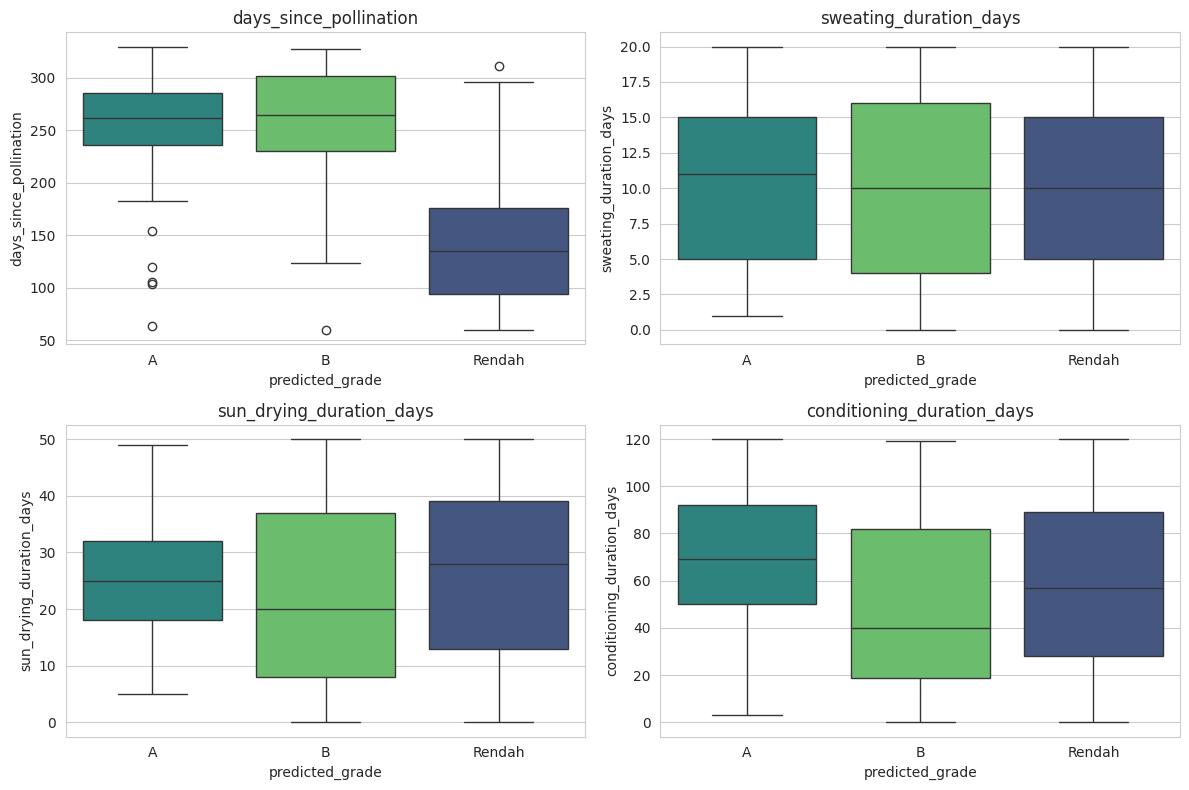

In [13]:
features_to_check = [
    "days_since_pollination",
    "sweating_duration_days",
    "sun_drying_duration_days",
    "conditioning_duration_days",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features_to_check):
    sns.boxplot(data=dataset_df, x="predicted_grade", y=feature, hue="predicted_grade", order=order, ax=ax, palette="viridis", legend=False)
    ax.set_title(feature)

plt.tight_layout()
plt.show()


### Correlation heatmap antar fitur numerik

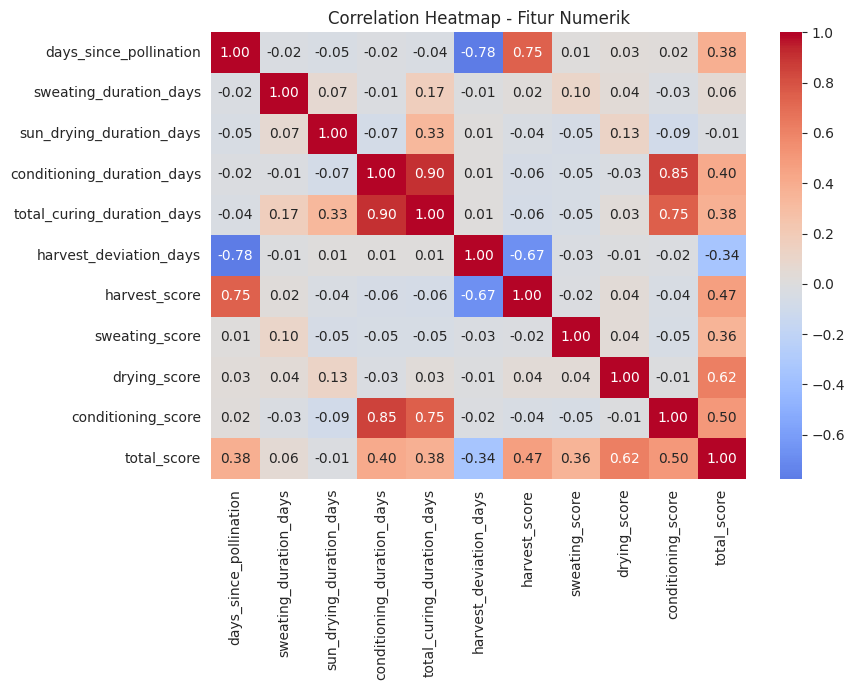

In [14]:
numeric_cols = [
    "days_since_pollination", "sweating_duration_days", "sun_drying_duration_days",
    "conditioning_duration_days", "total_curing_duration_days", "harvest_deviation_days",
    "harvest_score", "sweating_score", "drying_score", "conditioning_score", "total_score"
]

corr = dataset_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap - Fitur Numerik")
plt.tight_layout()
plt.show()


**Catatan interpretasi:** `harvest_deviation_days` secara desain berkorelasi negatif kuat
dengan `harvest_score` (makin jauh dari 240 hari, makin rendah skor) — ini expected by
construction, bukan temuan baru. Yang lebih penting dicek adalah apakah `sun_drying_duration_days`
vs `drying_score` sekarang searah positif (setelah revisi), bukan negatif seperti versi lama.

## 7. Train Random Forest Classifier

In [15]:
FEATURE_COLUMNS = [
    "days_since_pollination",
    "sweating_duration_days",
    "sun_drying_duration_days",
    "conditioning_duration_days",
    "total_curing_duration_days",
    "harvest_deviation_days",
]

# One-hot encode curing_method
dataset_df["curing_method_terkontrol"] = (dataset_df["curing_method"] == "terkontrol").astype(int)
FEATURE_COLUMNS_FINAL = FEATURE_COLUMNS + ["curing_method_terkontrol"]

X = dataset_df[FEATURE_COLUMNS_FINAL]
y = dataset_df["predicted_grade"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print("Confusion Matrix (rows=actual, cols=predicted), labels =", sorted(y.unique())) 
print(confusion_matrix(y_test, y_pred, labels=sorted(y.unique())))
print()
print(classification_report(y_test, y_pred))


Accuracy: 0.9071

Confusion Matrix (rows=actual, cols=predicted), labels = ['A', 'B', 'Rendah']
[[18  4  2]
 [ 4 31  1]
 [ 1  1 78]]

              precision    recall  f1-score   support

           A       0.78      0.75      0.77        24
           B       0.86      0.86      0.86        36
      Rendah       0.96      0.97      0.97        80

    accuracy                           0.91       140
   macro avg       0.87      0.86      0.87       140
weighted avg       0.91      0.91      0.91       140



In [16]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS_FINAL)
importances.sort_values(ascending=False)


days_since_pollination        0.454307
harvest_deviation_days        0.180813
sun_drying_duration_days      0.127267
total_curing_duration_days    0.087471
conditioning_duration_days    0.084301
sweating_duration_days        0.054329
curing_method_terkontrol      0.011513
dtype: float64

## 7b. Evaluasi Model — Lebih Lengkap

Accuracy dan confusion matrix teks di atas itu cukup buat cek cepat, tapi buat presentasi ke
juri (dan buat validasi diri sendiri), lebih baik ada:
1. Confusion matrix sebagai heatmap (lebih gampang dibaca)
2. Cross-validation (5-fold) — supaya angka accuracy ga cuma bergantung ke satu random train/test split
3. Feature importance sebagai bar chart, bukan cuma tabel angka

### Confusion matrix (heatmap)

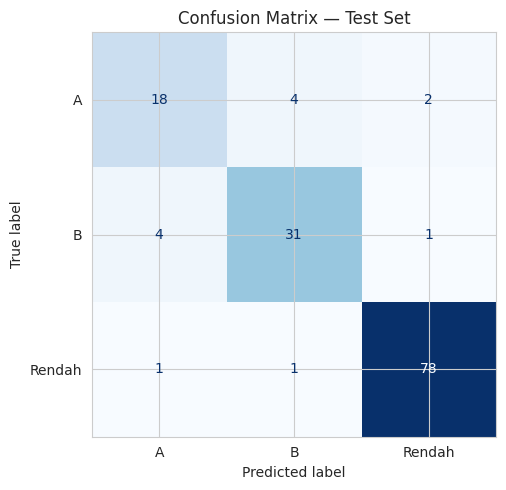

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


### Cross-validation (5-fold)

Single train/test split bisa kebetulan "beruntung" atau "sial" tergantung random split-nya.
5-fold cross-validation ngasih gambaran yang lebih stabil soal seberapa konsisten performa model.

In [18]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

print("Cross-validation accuracy per fold:", np.round(cv_scores, 4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Cross-validation accuracy per fold: [0.8643 0.9286 0.9071 0.9143 0.9143]
Mean CV accuracy: 0.9057 (+/- 0.0219)


### Feature importance (bar chart)

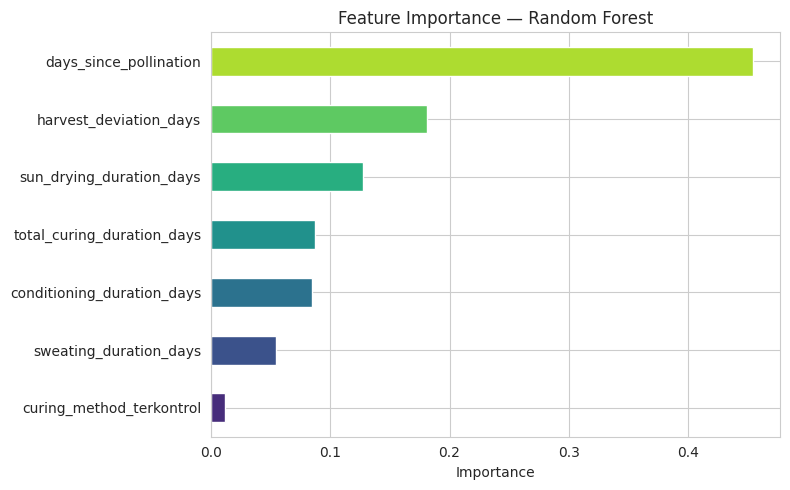

In [19]:
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances_sorted.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(importances_sorted)))
ax.set_title("Feature Importance — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


**Catatan interpretasi buat juri:** kalau `days_since_pollination` atau `harvest_deviation_days`
muncul sebagai fitur paling penting, itu align dengan temuan agronomis (waktu panen adalah
faktor paling determinan terhadap grade) — bagus buat storytelling saat presentasi. Kalau
sebaliknya (mis. fitur curing yang paling dominan), tetap valid, tapi framing-nya perlu disesuaikan.

## 8. Simpan Model Terlatih

In [20]:
os.makedirs("ml", exist_ok=True)
joblib.dump(model, "ml/grading_model.pkl")
joblib.dump(FEATURE_COLUMNS_FINAL, "ml/feature_columns.pkl")
print("Model tersimpan di ml/grading_model.pkl")


Model tersimpan di ml/grading_model.pkl


## 9. Catatan Sebelum Lanjut ke Backend API

1. **Verifikasi angka SNI kadar vanilin** sebelum dicantumkan di UI/pitch deck — ada
   ketidaksesuaian antara angka yang dikutip di dokumen produk (min. 1,00%) dengan
   angka yang muncul di beberapa sumber sekunder (min. 2,983% untuk Mutu I A). Cek
   dokumen SNI 01-0010-2002 resmi (BSN) untuk angka yang benar per kelas mutu.
2. Threshold di notebook ini tetap **rule-distillation dari sintesis literatur**, bukan
   data lapangan riil — sampaikan ke juri sebagai "estimasi awal berbasis SNI dan riset
   agribisnis," bukan hasil uji lab.
3. Kalau load `grading_model.pkl` di FastAPI, pastikan urutan kolom `FEATURE_COLUMNS_FINAL`
   sama persis dengan yang dipakai saat training (di-load bareng lewat `feature_columns.pkl`).
